In [1]:
# 10.6 Q2 - Image Compression with K-Means

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans

In [3]:
img = Image.open('datasets/sample_image_396x396.png')
print("Image size:", img.size, "mode:", img.mode)
img_arr = np.array(img)
print("Array shape:", img_arr.shape, "(H x W x 3)")
print("Pixel range:", img_arr.min(), "-", img_arr.max())

Image size: (396, 396) mode: RGB
Array shape: (396, 396, 3) (H x W x 3)
Pixel range: 18 - 247


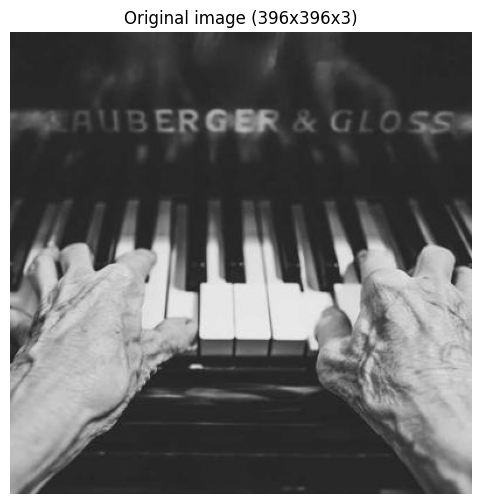

In [4]:
plt.figure(figsize=(6, 6))
plt.imshow(img_arr)
plt.title('Original image (' + str(img_arr.shape[0]) + 'x' + str(img_arr.shape[1]) + 'x3)')
plt.axis('off')
plt.show()

In [5]:
# Reshape image into a 2-D array of pixels

In [6]:
H, W, _ = img_arr.shape
pixels = img_arr.reshape(-1, 3).astype(np.float32)
print("Pixels array shape:", pixels.shape)
print("Total pixels:", pixels.shape[0])

Pixels array shape: (156816, 3)
Total pixels: 156816


In [7]:
# Cluster pixels into K colors (K = 8, 16, 32)

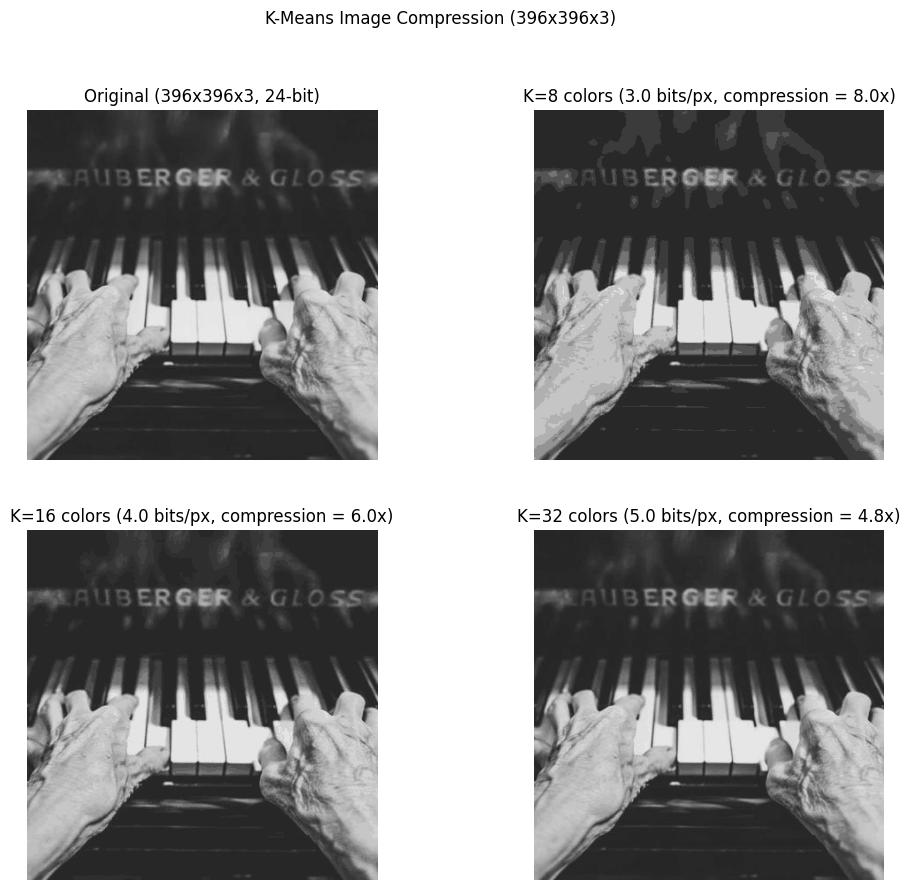

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
axes[0].imshow(img_arr)
axes[0].set_title('Original (' + str(img_arr.shape[0]) + 'x' + str(img_arr.shape[1]) + 'x3, 24-bit)')
axes[0].axis('off')

for ax, K in zip(axes[1:], [8, 16, 32]):
    km = KMeans(n_clusters=K, random_state=42, n_init=4)
    km.fit(pixels)
    new_pixels = km.cluster_centers_[km.labels_]
    new_img = new_pixels.reshape(H, W, 3).astype(np.uint8)
    ax.imshow(new_img)
    bpp = np.log2(K)
    ratio = 24 / bpp
    ax.set_title('K=' + str(K) + ' colors (' + str(round(bpp, 1)) + ' bits/px, compression = ' + str(round(ratio, 1)) + 'x)')
    ax.axis('off')
plt.suptitle('K-Means Image Compression (396x396x3)')
plt.show()

In [9]:
# Detailed comparison - Original vs K=16

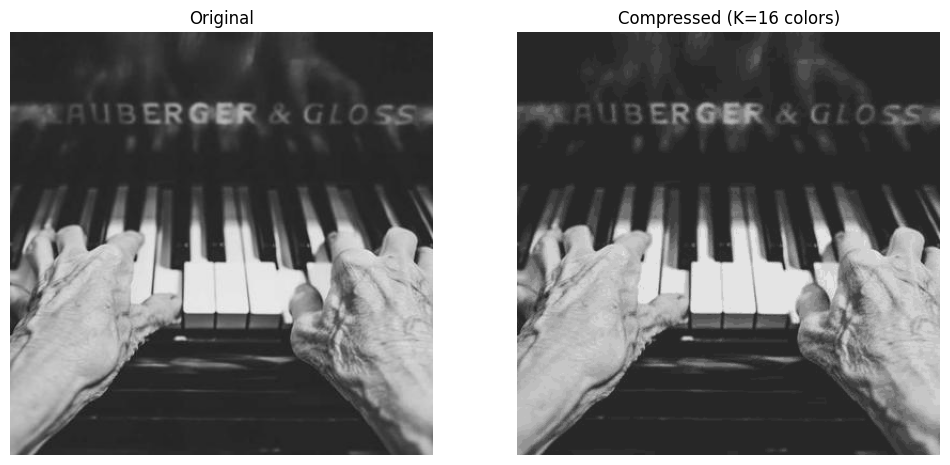

In [10]:
K = 16
km = KMeans(n_clusters=K, random_state=42, n_init=4)
km.fit(pixels)
new_pixels = km.cluster_centers_[km.labels_]
new_img = new_pixels.reshape(H, W, 3).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_arr); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(new_img); axes[1].set_title('Compressed (K=' + str(K) + ' colors)')
axes[1].axis('off')
plt.show()

In [11]:
# Save compressed image

In [12]:
Image.fromarray(new_img).save('outputs/compressed_K16.png')
print("Compressed image saved to outputs/compressed_K16.png")

Compressed image saved to outputs/compressed_K16.png
